In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load dataset
df = pd.read_csv("mars_wind_downsampled.csv")

# Display basic info
print(df.shape)
print(df.head())
print(df.describe())

(89378, 6)
   sol LMST_minute  BOOM1_HORIZONTAL_WIND_SPEED  BOOM2_HORIZONTAL_WIND_SPEED  \
0   36       1:32:                     0.404902                     0.795294   
1   36       1:33:                     0.301129                     0.497016   
2   36       1:34:                     0.560976                     1.012195   
3   36       1:35:                     0.962927                     1.395203   
4   36       1:36:                     1.875565                     2.044113   

   BOOM1_WIND_DIRECTION  BOOM2_WIND_DIRECTION  
0            114.981765            149.197451  
1            160.529677            177.545806  
2            110.529350            132.317967  
3            110.570000            121.586260  
4            110.570000            111.255484  
                sol  BOOM1_HORIZONTAL_WIND_SPEED  BOOM2_HORIZONTAL_WIND_SPEED  \
count  89378.000000                 88433.000000                 88123.000000   
mean     179.039596                     2.717584          

In [ ]:
df["AVG_WIND_SPEED"] = (
    df["BOOM1_HORIZONTAL_WIND_SPEED"] +
    df["BOOM2_HORIZONTAL_WIND_SPEED"]
) / 2

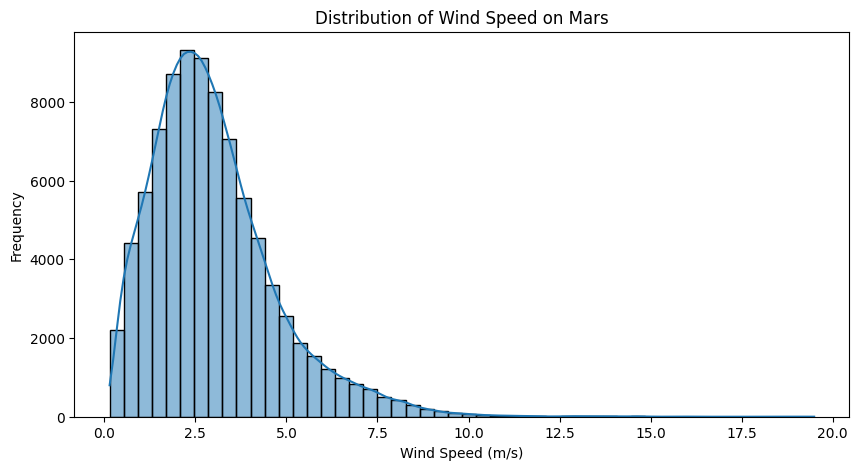

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["AVG_WIND_SPEED"], bins=50, kde=True)

plt.title("Distribution of Wind Speed on Mars")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Frequency")

plt.show()

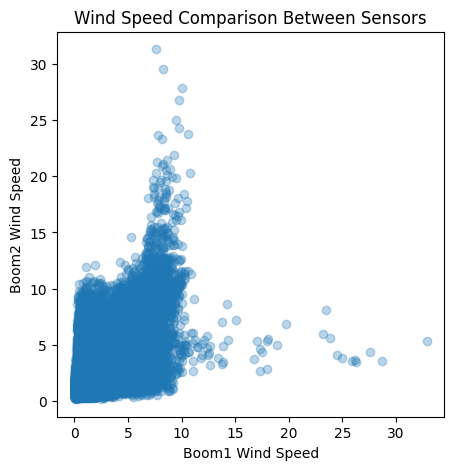

In [ ]:
plt.figure(figsize=(5,5))

plt.scatter(
    df["BOOM1_HORIZONTAL_WIND_SPEED"],
    df["BOOM2_HORIZONTAL_WIND_SPEED"],
    alpha=0.3
)

plt.xlabel("Boom1 Wind Speed")
plt.ylabel("Boom2 Wind Speed")

plt.title("Wind Speed Comparison Between Sensors")

plt.show()

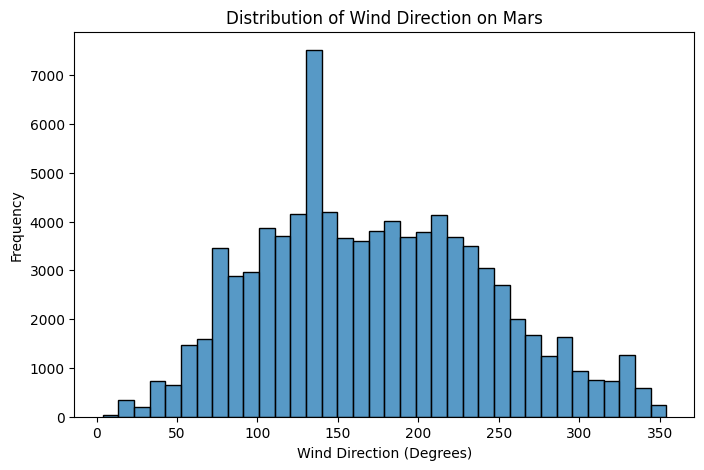

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["BOOM1_WIND_DIRECTION"], bins=36)

plt.xlabel("Wind Direction (Degrees)")
plt.ylabel("Frequency")

plt.title("Distribution of Wind Direction on Mars")

plt.show()

In [ ]:
# Extract hour
df["HOUR"] = df["LMST_minute"].str.split(":").str[0]
df["HOUR"] = df["HOUR"].astype(int)

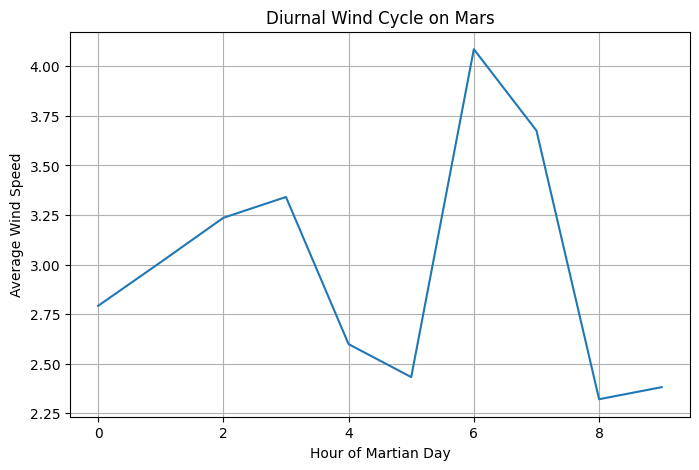

In [ ]:
diurnal_wind = df.groupby("HOUR")["AVG_WIND_SPEED"].mean()

plt.figure(figsize=(8,5))

plt.plot(diurnal_wind)

plt.xlabel("Hour of Martian Day")
plt.ylabel("Average Wind Speed")

plt.title("Diurnal Wind Cycle on Mars")

plt.grid()

plt.show()

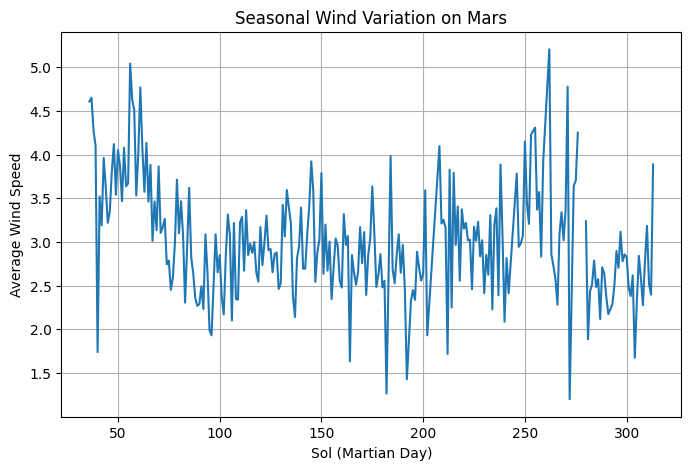

In [ ]:
seasonal_wind = df.groupby("sol")["AVG_WIND_SPEED"].mean()

plt.figure(figsize=(8,5))

plt.plot(seasonal_wind)

plt.xlabel("Sol (Martian Day)")
plt.ylabel("Average Wind Speed")

plt.title("Seasonal Wind Variation on Mars")

plt.grid()

plt.show()

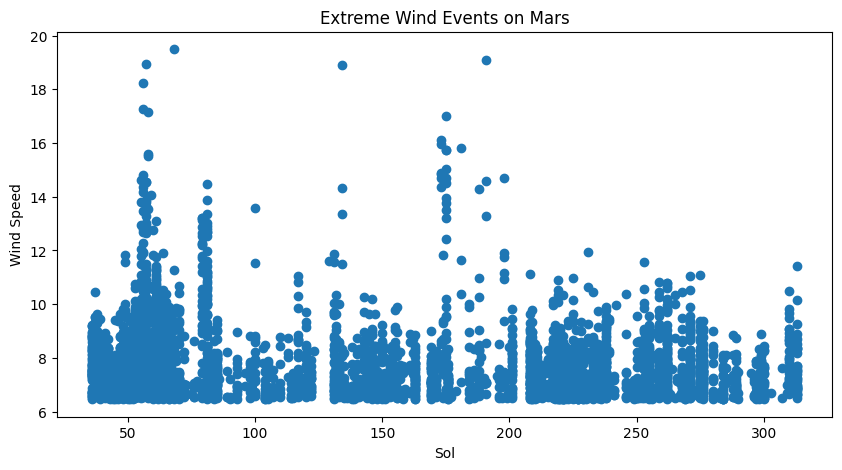

In [ ]:
threshold = df["AVG_WIND_SPEED"].mean() + 2 * df["AVG_WIND_SPEED"].std()

extreme_wind = df[df["AVG_WIND_SPEED"] > threshold]

plt.figure(figsize=(10,5))

plt.scatter(extreme_wind["sol"], extreme_wind["AVG_WIND_SPEED"])

plt.xlabel("Sol")
plt.ylabel("Wind Speed")

plt.title("Extreme Wind Events on Mars")

plt.show()

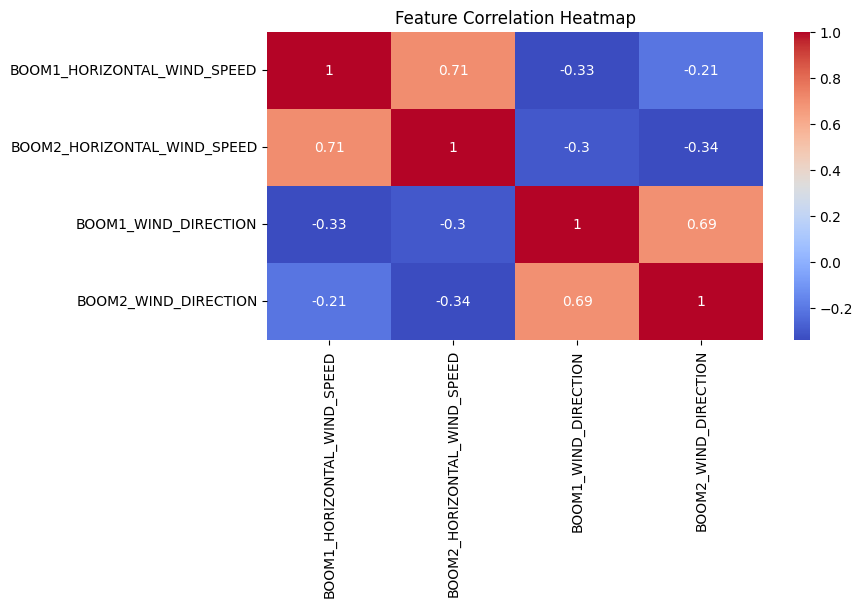

In [ ]:
plt.figure(figsize=(8,4))

corr = df[[
"BOOM1_HORIZONTAL_WIND_SPEED",
"BOOM2_HORIZONTAL_WIND_SPEED",
"BOOM1_WIND_DIRECTION",
"BOOM2_WIND_DIRECTION"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("mars_wind_downsampled.csv")

# Average wind speed from both sensors
df["AVG_WIND_SPEED"] = (
    df["BOOM1_HORIZONTAL_WIND_SPEED"] +
    df["BOOM2_HORIZONTAL_WIND_SPEED"]
) / 2

# Average wind direction
df["AVG_DIRECTION"] = (
    df["BOOM1_WIND_DIRECTION"] +
    df["BOOM2_WIND_DIRECTION"]
) / 2

print(df.head())

   sol LMST_minute  BOOM1_HORIZONTAL_WIND_SPEED  BOOM2_HORIZONTAL_WIND_SPEED  \
0   36       1:32:                     0.404902                     0.795294   
1   36       1:33:                     0.301129                     0.497016   
2   36       1:34:                     0.560976                     1.012195   
3   36       1:35:                     0.962927                     1.395203   
4   36       1:36:                     1.875565                     2.044113   

   BOOM1_WIND_DIRECTION  BOOM2_WIND_DIRECTION  AVG_WIND_SPEED  AVG_DIRECTION  
0            114.981765            149.197451        0.600098     132.089608  
1            160.529677            177.545806        0.399073     169.037742  
2            110.529350            132.317967        0.786585     121.423659  
3            110.570000            121.586260        1.179065     116.078130  
4            110.570000            111.255484        1.959839     110.912742  


In [ ]:
pip install windrose

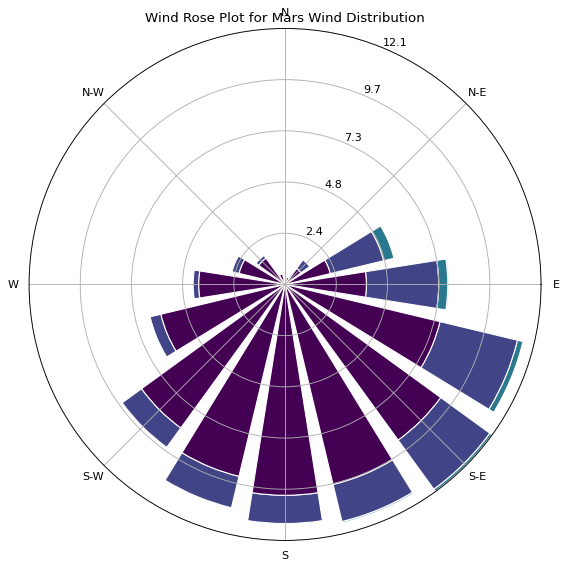

<Figure size 400x200 with 0 Axes>

In [ ]:
from windrose import WindroseAxes

ax = WindroseAxes.from_ax()

ax.bar(
    df["AVG_DIRECTION"],
    df["AVG_WIND_SPEED"],
    normed=True,
    opening=0.8,
    edgecolor='white'
)

ax.set_title("Wind Rose Plot for Mars Wind Distribution")
plt.figure(figsize=(4,2))
plt.show()

This plot shows:

1.dominant wind directions on Mars

2.which directions produce strongest winds

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Wind Pattern Clustering (K-Means)

| Cluster   | Meaning       |
| --------- | ------------- |
| Cluster 0 | Calm wind     |
| Cluster 1 | Moderate wind |
| Cluster 2 | Strong wind   |


In [ ]:
features = df[["AVG_WIND_SPEED","AVG_DIRECTION"]]

features = features.dropna()

scaler = StandardScaler()
X = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')

df["cluster"] = np.nan # Initialize 'cluster' column with NaNs
df.loc[features.index, "cluster"] = kmeans.fit_predict(X)

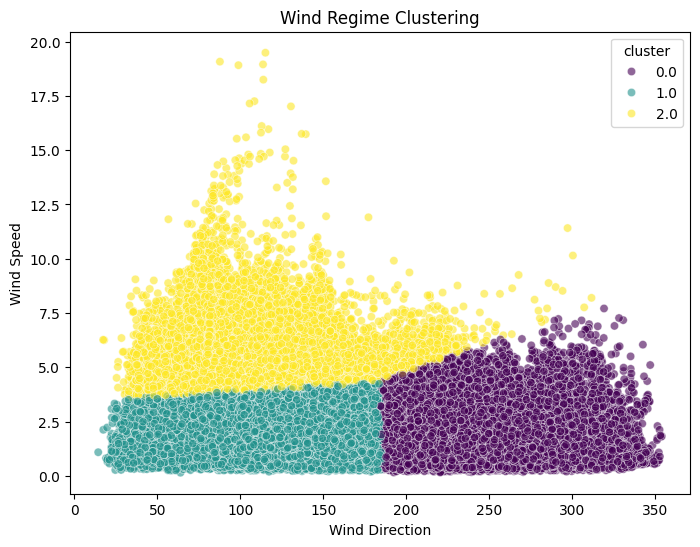

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["AVG_DIRECTION"],
    y=df["AVG_WIND_SPEED"],
    hue=df["cluster"],
    palette="viridis",
    alpha=0.6
)

plt.xlabel("Wind Direction")
plt.ylabel("Wind Speed")
plt.title("Wind Regime Clustering")

plt.show()

LSTM / GRU

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
data = df["AVG_WIND_SPEED"].dropna().values.reshape(-1,1)

scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)

In [ ]:
def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

seq_length = 20

X, y = create_sequences(data_scaled, seq_length)

In [ ]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
lstm_model = Sequential()

lstm_model.add(LSTM(50, return_sequences=True, input_shape=(seq_length,1)))
lstm_model.add(LSTM(50))
lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0028
Epoch 2/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0022
Epoch 3/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0022
Epoch 4/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0022
Epoch 5/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0022
Epoch 6/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0022
Epoch 7/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0022
Epoch 8/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0022
Epoch 9/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0022
Epoch 10/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0022
Epoch 11/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0022
Epoch 12/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0022
Epoch 13/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0022
Epoch 14/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0022
Epoch 15/30
1090/1090 ━━━━━━

In [ ]:
from tensorflow.keras.layers import GRU

In [ ]:
gru_model = Sequential()

gru_model.add(GRU(50, return_sequences=True, input_shape=(seq_length,1)))
gru_model.add(GRU(50))
gru_model.add(Dense(1))

gru_model.compile(
    optimizer="adam",
    loss="mse"
)

gru_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64
)

Epoch 1/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0024
Epoch 2/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0022
Epoch 3/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0022
Epoch 4/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0022
Epoch 5/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0022
Epoch 6/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0022
Epoch 7/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0022
Epoch 8/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0022
Epoch 9/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0022
Epoch 10/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0022
Epoch 11/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0022
Epoch 12/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0022
Epoch 13/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0022
Epoch 14/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0022
Epoch 15/30
1090/1090 ━━━━━━━

In [ ]:
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)
gru_pred = scaler.inverse_transform(gru_pred)

y_test_actual = scaler.inverse_transform(y_test)

545/545 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
545/545 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

In [ ]:
lstm_metrics = evaluate_model(y_test_actual, lstm_pred)
gru_metrics = evaluate_model(y_test_actual, gru_pred)

print("LSTM:", lstm_metrics)
print("GRU:", gru_metrics)

LSTM: (0.49278253219117485, np.float64(0.7309463449164699), 0.7685587491117387)
GRU: (0.4924764297636743, np.float64(0.7336367361187758), 0.7668518839377343)


545/545 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
545/545 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


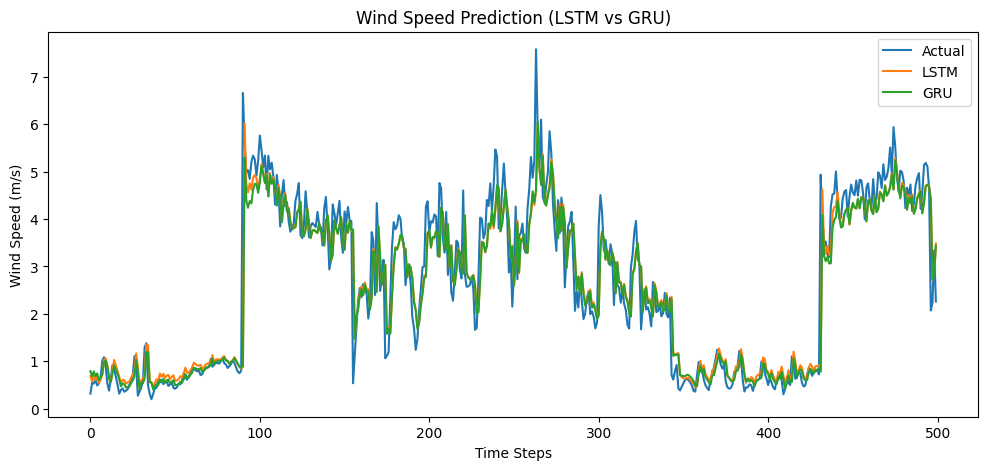

In [ ]:
# Predictions
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

# Inverse scaling
lstm_pred = scaler.inverse_transform(lstm_pred)
gru_pred = scaler.inverse_transform(gru_pred)
y_test_actual = scaler.inverse_transform(y_test)

# Plot
plt.figure(figsize=(12,5))

plt.plot(y_test_actual[:500], label="Actual")
plt.plot(lstm_pred[:500], label="LSTM")
plt.plot(gru_pred[:500], label="GRU")

plt.legend()
plt.title("Wind Speed Prediction (LSTM vs GRU)")
plt.xlabel("Time Steps")
plt.ylabel("Wind Speed (m/s)")

plt.show()

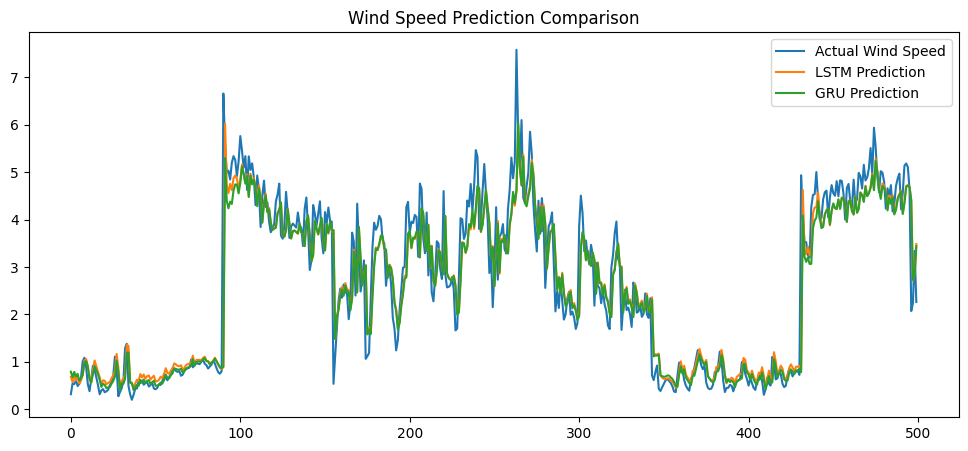

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_test_actual[:500], label="Actual Wind Speed")
plt.plot(lstm_pred[:500], label="LSTM Prediction")
plt.plot(gru_pred[:500], label="GRU Prediction")

plt.legend()

plt.title("Wind Speed Prediction Comparison")

plt.show()

In [ ]:
last_sequence = data_scaled[-seq_length:]

predictions = []

current_seq = last_sequence.reshape(1,seq_length,1)

for i in range(60):

    pred = gru_model.predict(current_seq)

    predictions.append(pred[0,0])

    # Reshape pred to (1, 1, 1) to match dimensions of current_seq
    current_seq = np.append(current_seq[:,1:,:], pred.reshape(1,1,1), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━

In [ ]:
predictions = scaler.inverse_transform(np.array(predictions).reshape(-1,1))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

# Load data
df = pd.read_csv("mars_wind_downsampled.csv")

# Create features
df["AVG_WIND_SPEED"] = (
    df["BOOM1_HORIZONTAL_WIND_SPEED"] +
    df["BOOM2_HORIZONTAL_WIND_SPEED"]
) / 2

# Extract hour
df["HOUR"] = df["LMST_minute"].str.split(":").str[0].astype(int)

# Use MULTIVARIATE features
features = df[["AVG_WIND_SPEED", "HOUR"]].dropna()

# Scale
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(features)

In [ ]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, 0])  # predict wind speed only
    return np.array(X), np.array(y)

seq_length = 60   # increased from 20
X, y = create_sequences(data_scaled, seq_length)

# Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_length, 2)),
    LSTM(32),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")

lstm_model.fit(X_train, y_train, epochs=30, batch_size=64)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1089/1089 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0030
Epoch 2/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0022
Epoch 3/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0022
Epoch 4/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0022
Epoch 5/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0022
Epoch 6/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0022
Epoch 7/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0022
Epoch 8/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0022
Epoch 9/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0021
Epoch 10/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0021
Epoch 11/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0021
Epoch 12/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0021
Epoch 13/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0021
Epoch 14/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0021
Epoch 15/30
1089/1089 ━━━━━━━━━━━━

In [ ]:
gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(seq_length, 2)),
    GRU(32),
    Dense(1)
])

gru_model.compile(optimizer="adam", loss="mse")

gru_model.fit(X_train, y_train, epochs=30, batch_size=64)

Epoch 1/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0025
Epoch 2/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0022
Epoch 3/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0022
Epoch 4/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0022
Epoch 5/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0022
Epoch 6/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0022
Epoch 7/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0022
Epoch 8/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0022
Epoch 9/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0022
Epoch 10/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0022
Epoch 11/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0022
Epoch 12/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0021
Epoch 13/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0021
Epoch 14/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 0.0021
Epoch 15/30
1089/1089 ━━━

In [ ]:
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

# Inverse scaling ONLY wind speed
def inverse_transform(pred):
    temp = np.zeros((len(pred), 2))
    temp[:,0] = pred.flatten()
    return scaler.inverse_transform(temp)[:,0]

lstm_pred = inverse_transform(lstm_pred)
gru_pred = inverse_transform(gru_pred)

y_test_actual = inverse_transform(y_test.reshape(-1,1))

545/545 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
545/545 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


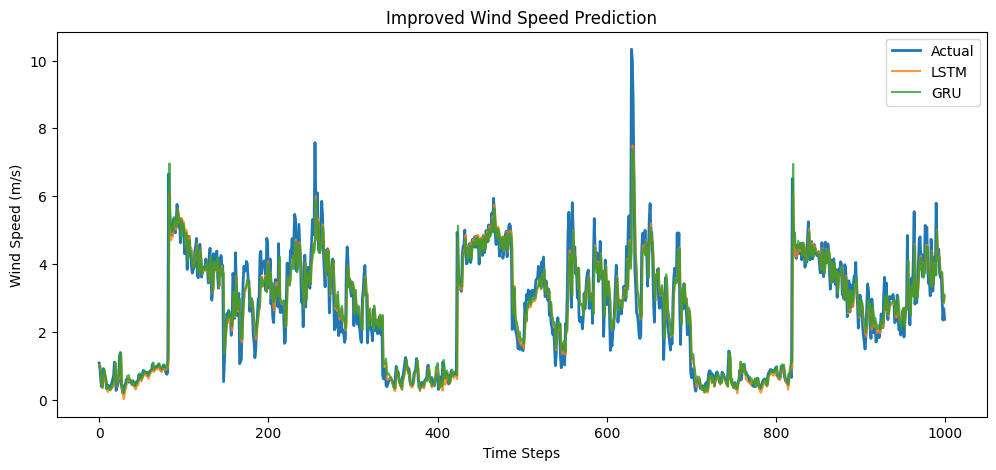

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_test_actual[:1000], label="Actual", linewidth=2)
plt.plot(lstm_pred[:1000], label="LSTM", alpha=0.8)
plt.plot(gru_pred[:1000], label="GRU", alpha=0.8)

plt.legend()
plt.title("Improved Wind Speed Prediction")
plt.xlabel("Time Steps")
plt.ylabel("Wind Speed (m/s)")

plt.show()

In [ ]:
future_steps = 1440

last_seq = data_scaled[-seq_length:]

current_lstm = last_seq.reshape(1, seq_length, 2)
current_gru = last_seq.reshape(1, seq_length, 2)

lstm_future, gru_future = [], []

for i in range(future_steps):

    # Predict
    lstm_p = lstm_model.predict(current_lstm, verbose=0)
    gru_p = gru_model.predict(current_gru, verbose=0)

    lstm_future.append(lstm_p[0,0])
    gru_future.append(gru_p[0,0])

    # Keep hour cycling (important fix)
    next_hour = (current_lstm[0,-1,1] * 23 + 1) % 24 / 23

    new_lstm = np.array([[lstm_p[0,0], next_hour]])
    new_gru = np.array([[gru_p[0,0], next_hour]])

    current_lstm = np.append(current_lstm[:,1:,:], new_lstm.reshape(1,1,2), axis=1)
    current_gru = np.append(current_gru[:,1:,:], new_gru.reshape(1,1,2), axis=1)

# Convert back
lstm_future = inverse_transform(np.array(lstm_future).reshape(-1,1))
gru_future = inverse_transform(np.array(gru_future).reshape(-1,1))

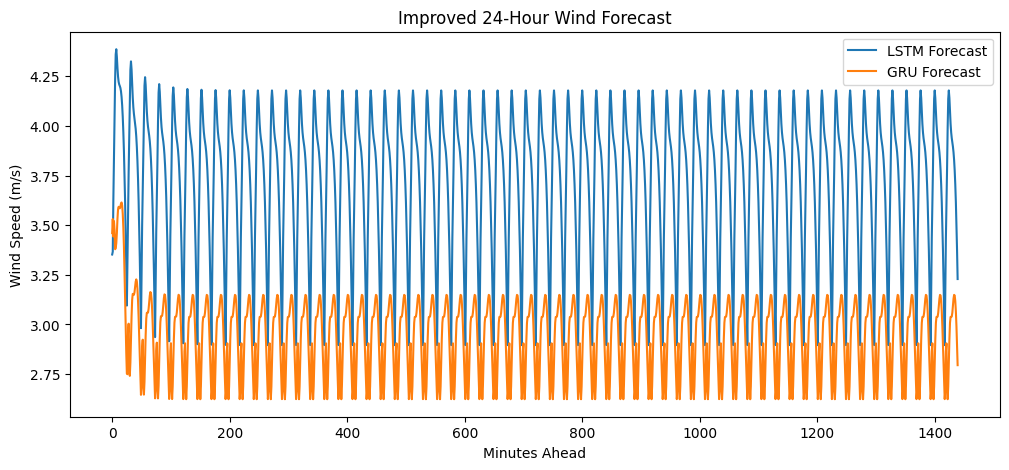

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(lstm_future, label="LSTM Forecast")
plt.plot(gru_future, label="GRU Forecast")

plt.title("Improved 24-Hour Wind Forecast")
plt.xlabel("Minutes Ahead")
plt.ylabel("Wind Speed (m/s)")

plt.legend()
plt.show()

more features better scaling and dropout, early stopping

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
df = pd.read_csv("mars_wind_downsampled.csv")

# Create features
df["AVG_WIND_SPEED"] = (
    df["BOOM1_HORIZONTAL_WIND_SPEED"] +
    df["BOOM2_HORIZONTAL_WIND_SPEED"]
) / 2

df["AVG_DIRECTION"] = (
    df["BOOM1_WIND_DIRECTION"] +
    df["BOOM2_WIND_DIRECTION"]
) / 2

# Extract hour
df["HOUR"] = df["LMST_minute"].str.split(":").str[0].astype(int)

# Select features
features = df[["AVG_WIND_SPEED", "HOUR", "AVG_DIRECTION"]].dropna()

In [ ]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(features)

In [ ]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, 0])  # predict wind speed
    return np.array(X), np.array(y)

seq_length = 60

X, y = create_sequences(data_scaled, seq_length)

# Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_length, 3)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")

lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 0.3200 - val_loss: 0.1790
Epoch 2/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.2788 - val_loss: 0.1807
Epoch 3/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.2752 - val_loss: 0.1787
Epoch 4/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.2744 - val_loss: 0.1781
Epoch 5/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.2733 - val_loss: 0.1773
Epoch 6/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.2709 - val_loss: 0.1789
Epoch 7/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.2712 - val_loss: 0.1827
Epoch 8/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.2712 - val_loss: 0.1786
Epoch 9/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 0.2705 - val_loss: 0.1773
Epoch 10/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.2703 - val_loss: 0.1772
Epoch 11/30
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.2700 - val_loss: 0.1771
Epoch 12

In [ ]:
gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(seq_length, 3)),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(optimizer="adam", loss="mse")

gru_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/25
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.3006 - val_loss: 0.1810
Epoch 2/25
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.2781 - val_loss: 0.1795
Epoch 3/25
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.2759 - val_loss: 0.1774
Epoch 4/25
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.2739 - val_loss: 0.1775
Epoch 5/25
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.2727 - val_loss: 0.1770


In [ ]:
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

# Inverse transform (only wind speed)
def inverse_transform(pred):
    temp = np.zeros((len(pred), 3))
    temp[:,0] = pred.flatten()
    return scaler.inverse_transform(temp)[:,0]

lstm_pred = inverse_transform(lstm_pred)
gru_pred = inverse_transform(gru_pred)

y_test_actual = inverse_transform(y_test.reshape(-1,1))

545/545 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
545/545 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [ ]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{name} MAE:", mae)
    print(f"{name} RMSE:", rmse)
    print(f"{name} R2:", r2)
    print()

evaluate(y_test_actual, lstm_pred, "LSTM")
evaluate(y_test_actual, gru_pred, "GRU")

LSTM MAE: 0.4907322256718425
LSTM RMSE: 0.727759055858447
LSTM R2: 0.7704699923511802

GRU MAE: 0.5070502915845239
GRU RMSE: 0.7366788533603709
GRU R2: 0.7648090309665667



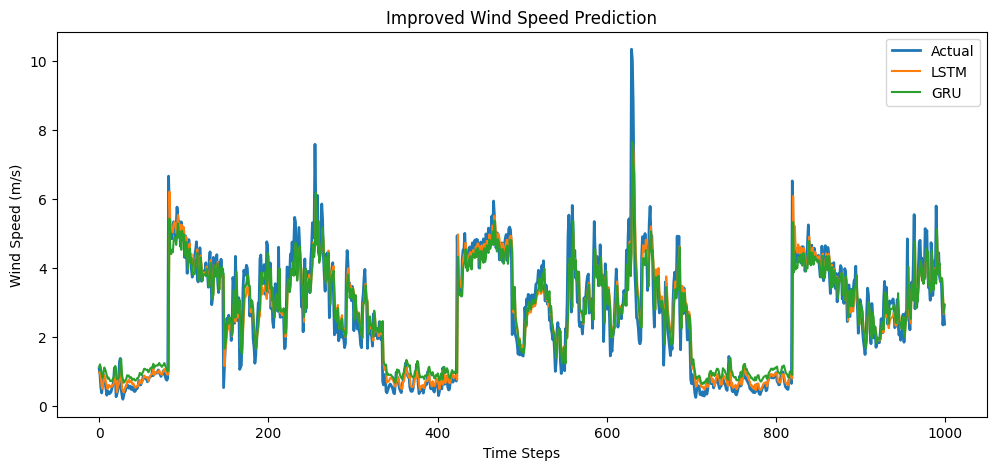

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_test_actual[:1000], label="Actual", linewidth=2)
plt.plot(lstm_pred[:1000], label="LSTM")
plt.plot(gru_pred[:1000], label="GRU")

plt.legend()
plt.title("Improved Wind Speed Prediction")
plt.xlabel("Time Steps")
plt.ylabel("Wind Speed (m/s)")

plt.show()

In [ ]:
future_steps = 1440  # 24 hours (minute data)

# Take last sequence
last_seq = data_scaled[-seq_length:]

current_lstm = last_seq.reshape(1, seq_length, 3)
current_gru = last_seq.reshape(1, seq_length, 3)

lstm_future = []
gru_future = []

In [ ]:
for i in range(future_steps):

    # Predict next step
    lstm_pred = lstm_model.predict(current_lstm, verbose=0)
    gru_pred = gru_model.predict(current_gru, verbose=0)

    lstm_future.append(lstm_pred[0,0])
    gru_future.append(gru_pred[0,0])

    # Get last hour & direction
    last_hour = current_lstm[0, -1, 1]
    last_dir = current_lstm[0, -1, 2]

    # Convert scaled hour → real → update → rescale
    hour_real = last_hour * 23
    next_hour = (hour_real + 1) % 24
    next_hour_scaled = next_hour / 23

    # Keep direction same (or slowly vary)
    next_dir = last_dir

    # Create next input row
    new_lstm = np.array([[lstm_pred[0,0], next_hour_scaled, next_dir]])
    new_gru  = np.array([[gru_pred[0,0], next_hour_scaled, next_dir]])

    # Update sequences
    current_lstm = np.append(current_lstm[:,1:,:], new_lstm.reshape(1,1,3), axis=1)
    current_gru  = np.append(current_gru[:,1:,:], new_gru.reshape(1,1,3), axis=1)

In [ ]:
def inverse_transform(pred):
    temp = np.zeros((len(pred), 3))
    temp[:,0] = pred.flatten()
    return scaler.inverse_transform(temp)[:,0]

lstm_future = inverse_transform(np.array(lstm_future).reshape(-1,1))
gru_future  = inverse_transform(np.array(gru_future).reshape(-1,1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 0.4348 - val_loss: 0.2766
Epoch 2/25
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.4057 - val_loss: 0.2752
Epoch 3/25
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.3998 - val_loss: 0.2777
Epoch 4/25
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 0.3938 - val_loss: 0.2717
Epoch 5/25
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.3925 - val_loss: 0.2718
Epoch 1/25
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 0.4245 - val_loss: 0.2765
Epoch 2/25
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.4051 - val_loss: 0.2907
Epoch 3/25
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 39s 9ms/step - loss: 0.4003 - val_loss: 0.2768
Epoch 4/25
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.3976 - val_loss: 0.2745
Epoch 5/25
2178/2178 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 0.3954 - val_loss: 0.2699
      Model       MAE      RMSE        R2
0      LSTM  0.516940  0.743790  0.760247
1       GRU  0.503889  

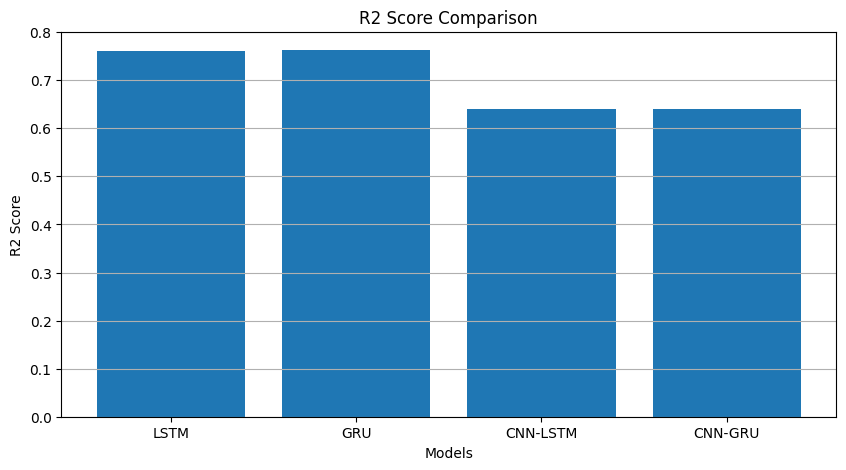

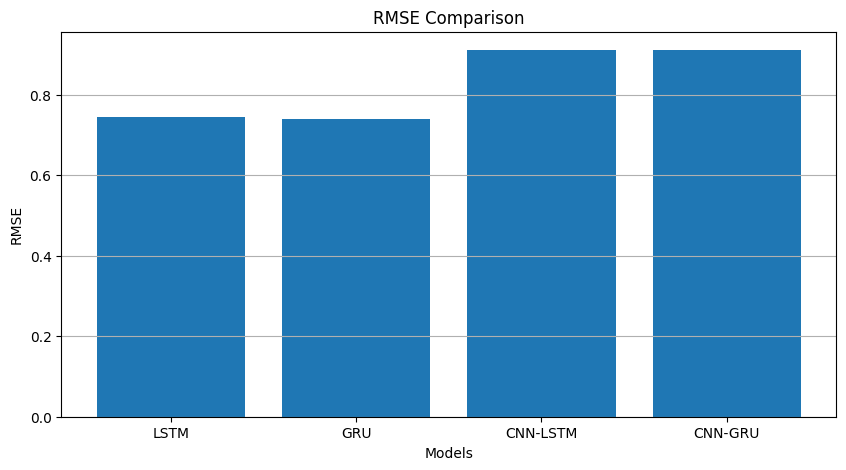

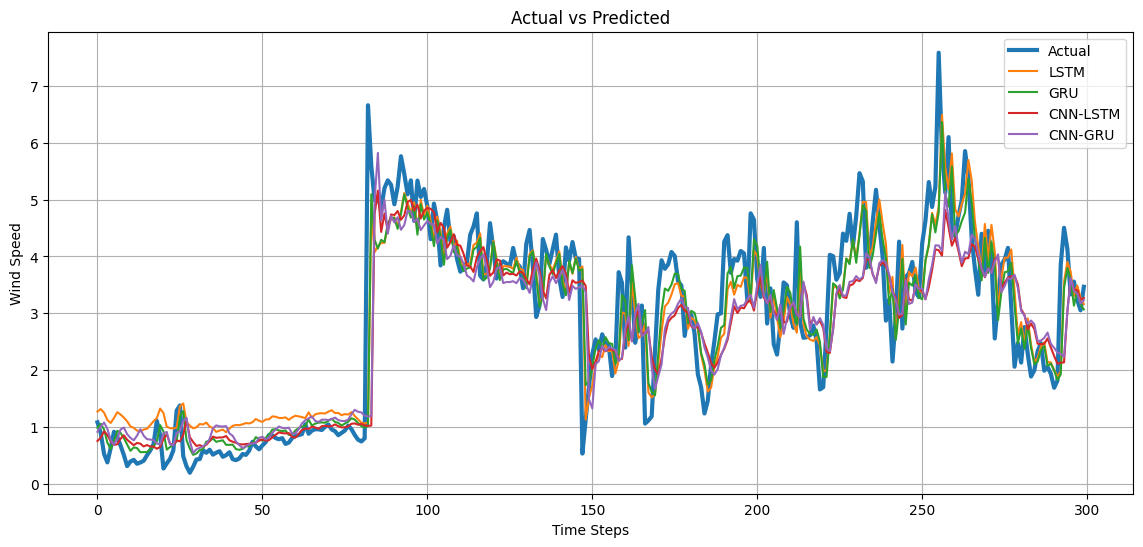

Model Ranking:
      Model       MAE      RMSE        R2
0       GRU  0.503889  0.739810  0.762806
1      LSTM  0.516940  0.743790  0.760247
2   CNN-GRU  0.640297  0.910509  0.640720
3  CNN-LSTM  0.631921  0.910731  0.640545

Best Model Selected Using RMSE + R2 : GRU

Best Model Metrics:
RMSE : 0.7398097768229245
R2   : 0.7628056350108317
MAE  : 0.5038891647207469


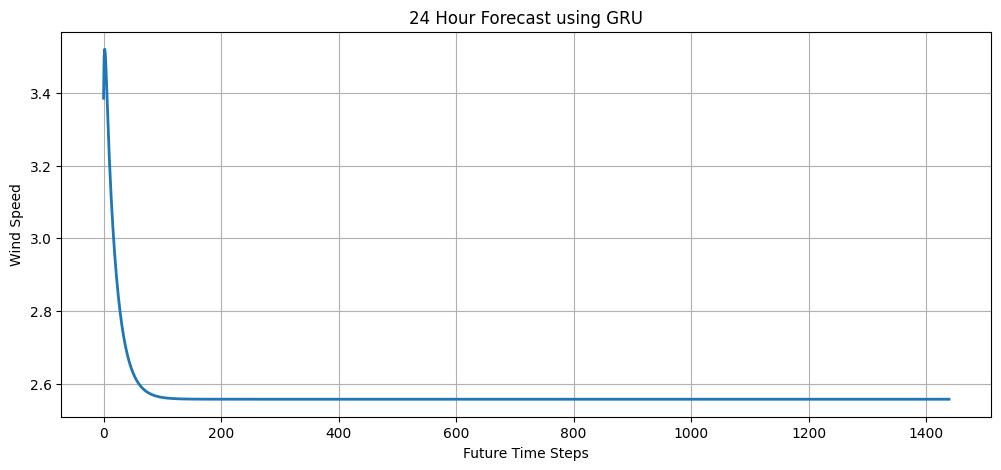

Forecast saved as best_model_24hr_forecast.csv


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, LSTM, GRU,
    Conv1D, MaxPooling1D, Flatten
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def inverse_transform_target(pred):
    temp = np.zeros((len(pred), 3))
    temp[:, 0] = pred.flatten()
    return scaler.inverse_transform(temp)[:, 0]

# ==========================================================
# 1. CNN-LSTM MODEL
# ==========================================================
cnn_lstm_model = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu',
           input_shape=(seq_length, 3)),
    MaxPooling1D(pool_size=2),

    LSTM(64, return_sequences=True),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(1)
])

cnn_lstm_model.compile(optimizer='adam', loss='mse')

cnn_lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================================
# 2. CNN-GRU MODEL
# ==========================================================
cnn_gru_model = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu',
           input_shape=(seq_length, 3)),
    MaxPooling1D(pool_size=2),

    GRU(64, return_sequences=True),
    Dropout(0.2),

    GRU(32),
    Dropout(0.2),

    Dense(1)
])

cnn_gru_model.compile(optimizer='adam', loss='mse')

cnn_gru_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================================
# 3. PREDICTIONS
# ==========================================================
lstm_pred     = lstm_model.predict(X_test, verbose=0)
gru_pred      = gru_model.predict(X_test, verbose=0)
cnn_lstm_pred = cnn_lstm_model.predict(X_test, verbose=0)
cnn_gru_pred  = cnn_gru_model.predict(X_test, verbose=0)

# inverse scale
y_test_actual = inverse_transform_target(y_test.reshape(-1,1))

lstm_pred     = inverse_transform_target(lstm_pred)
gru_pred      = inverse_transform_target(gru_pred)
cnn_lstm_pred = inverse_transform_target(cnn_lstm_pred)
cnn_gru_pred  = inverse_transform_target(cnn_gru_pred)

# ==========================================================
# 4. EVALUATION METRICS
# ==========================================================
def get_metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

results = []
results.append(get_metrics(y_test_actual, lstm_pred, "LSTM"))
results.append(get_metrics(y_test_actual, gru_pred, "GRU"))
results.append(get_metrics(y_test_actual, cnn_lstm_pred, "CNN-LSTM"))
results.append(get_metrics(y_test_actual, cnn_gru_pred, "CNN-GRU"))

results_df = pd.DataFrame(results)
print(results_df)

# ==========================================================
# 5. BAR GRAPH OF ALL MODELS
# ==========================================================
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["R2"])
plt.title("R2 Score Comparison")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.grid(axis='y')
plt.show()

plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("RMSE Comparison")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.grid(axis='y')
plt.show()

# ==========================================================
# 6. ACTUAL VS PREDICTED GRAPH
# ==========================================================
plt.figure(figsize=(14,6))

plt.plot(y_test_actual[:300], label="Actual", linewidth=3)
plt.plot(lstm_pred[:300], label="LSTM")
plt.plot(gru_pred[:300], label="GRU")
plt.plot(cnn_lstm_pred[:300], label="CNN-LSTM")
plt.plot(cnn_gru_pred[:300], label="CNN-GRU")

plt.title("Actual vs Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Wind Speed")
plt.legend()
plt.grid()
plt.show()

# ==========================================================
# 7. BEST MODEL
# ==========================================================


results_df = results_df.sort_values(
    by=["RMSE", "R2"],
    ascending=[True, False]
).reset_index(drop=True)

print("Model Ranking:")
print(results_df)

best_row = results_df.iloc[0]

best_model_name = best_row["Model"]

print("\nBest Model Selected Using RMSE + R2 :", best_model_name)

if best_model_name == "LSTM":
    best_model = lstm_model

elif best_model_name == "GRU":
    best_model = gru_model

elif best_model_name == "CNN-LSTM":
    best_model = cnn_lstm_model

elif best_model_name == "CNN-GRU":
    best_model = cnn_gru_model

print("\nBest Model Metrics:")
print("RMSE :", best_row["RMSE"])
print("R2   :", best_row["R2"])
print("MAE  :", best_row["MAE"])

# ==========================================================
# 8. 24 HOURS FUTURE FORECAST
# If minute data = 1440 steps
# If hourly data = 24 steps
# ----------------------------------------------------------
future_steps = 1440

last_seq = data_scaled[-seq_length:]
current_seq = last_seq.reshape(1, seq_length, 3)

future_preds = []

for i in range(future_steps):

    pred = best_model.predict(current_seq, verbose=0)
    future_preds.append(pred[0,0])

    last_hour = current_seq[0, -1, 1]
    last_dir  = current_seq[0, -1, 2]

    new_row = np.array([[pred[0,0], last_hour, last_dir]])

    current_seq = np.append(
        current_seq[:,1:,:],
        new_row.reshape(1,1,3),
        axis=1
    )

# inverse scale
future_preds = inverse_transform_target(
    np.array(future_preds).reshape(-1,1)
)

# ==========================================================
# 9. FORECAST GRAPH
# ==========================================================
plt.figure(figsize=(12,5))
plt.plot(future_preds, linewidth=2)
plt.title(f"24 Hour Forecast using {best_model_name}")
plt.xlabel("Future Time Steps")
plt.ylabel("Wind Speed")
plt.grid()
plt.show()

# ==========================================================
# 10. SAVE FORECAST
# ==========================================================
forecast_df = pd.DataFrame({
    "Step": np.arange(1, future_steps+1),
    "Predicted_WindSpeed": future_preds
})

forecast_df.to_csv("best_model_24hr_forecast.csv", index=False)
print("Forecast saved as best_model_24hr_forecast.csv")